# CellPlanner Demo

This notebook starts the specialized tower/cell planning workflow.

Current `CellPlanner` scope:

- instantiate configured cell sites as connected cell devices
- instantiate all other sites as client devices
- build direct primary-technology candidate links
- optionally filter candidates by sector antenna azimuth/beamwidth
- compute metrics through `GraphPlanner`
- run RPL for direct one-hop cell assignment
- report client service at site/interface level

Later cells can be added for cell-site selection and relay recovery.

In [ ]:
import importlib
import cisei_lib.planners.cell_planner as cp

importlib.reload(cp)

In [1]:
from pathlib import Path
import sys
import math

import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "cisei_lib").exists():
    REPO_ROOT = Path("/workspaces/network_service")

sys.path.insert(0, str(REPO_ROOT))

from cisei_lib.planners import CellPlanner
import cisei_lib.planners.planner_reports as reports
from cisei_lib.io.async_geo_service_pool import AsyncGeoServicePool

CONFIG_PATH = REPO_ROOT / "tests/jupyter/cell_planner_sector.toml"
POINTS_PATH = REPO_ROOT / "tests/jupyter/points.csv"

CELL_SITE_IDS = {"itallia", "torre"}
WORKING_CRS = "EPSG:31982"

## 1. Load Site Records

The CSV stays outside the planner. The specialization receives already prepared records.

In [2]:
points = pd.read_csv(POINTS_PATH)
points["id"] = points["id"].astype(str).str.strip()
points

,id,lat,lon,ant_h
0,copel,-25.432731,-49.339207,7
1,tenis,-25.425357,-49.292122,7
2,praca_29,-25.427624,-49.285643,7
3,torre,-25.423532,-49.293992,100
4,woodland,-25.426584,-49.330740,7
5,deneka,-25.423934,-49.325575,7
6,cemiterio,-25.420709,-49.313294,7
7,saturno,-25.427867,-49.343001,7
8,decatlon,-25.428662,-49.322405,7
9,shopping,-25.435108,-49.317711,7


## 2. Create CellPlanner

The TOML defines sector antenna/interface/device/metric profiles. `CellPlanner` decides which sites are cells and builds direct sector-aware candidates.

### Manual Per-Site Profile Override

The default `cell_profile` applies to all cell sites. Use `overrides_by_id` to change one tower before candidate generation. In this example, `itallia` uses `cell_sector_2x120`, while `torre` keeps the default `cell_sector_3x120`.


In [3]:
cell = CellPlanner.from_toml(
    CONFIG_PATH,
    cell_site_ids=CELL_SITE_IDS,
    working_crs=WORKING_CRS,
    primary_tech="lte",
    cell_profile="cell_sector_3x120",
    client_profile="lte_leaf",
)

cell.add_sites(
    points,
    overrides_by_id={
        # Manual sector-count override: itallia uses only two predefined sectors.
        "itallia": {"device_profile": "cell_sector_2x120"},
    },
)

print("sites:", len(cell.graph.nodes))
print("interfaces:", len(cell.graph.rpl_nodes()))
print("cell sites:", sorted(cell.cell_site_ids))
print("primary tech:", cell.primary_tech)

sites: 13
interfaces: 16
cell sites: ['itallia', 'torre']
primary tech: lte


In [4]:
reports.config_table(cell.graph, "devices")

,device_id,site_id,connected,can_route,rank,mount_height_m,device_profile
0,copel:d0,copel,False,False,inf,7.0,lte_leaf
1,tenis:d0,tenis,False,False,inf,7.0,lte_leaf
2,praca_29:d0,praca_29,False,False,inf,7.0,lte_leaf
3,torre:d0,torre,True,True,0.0,100.0,cell_sector_3x120
4,woodland:d0,woodland,False,False,inf,7.0,lte_leaf
5,deneka:d0,deneka,False,False,inf,7.0,lte_leaf
6,cemiterio:d0,cemiterio,False,False,inf,7.0,lte_leaf
7,saturno:d0,saturno,False,False,inf,7.0,lte_leaf
8,decatlon:d0,decatlon,False,False,inf,7.0,lte_leaf
9,shopping:d0,shopping,False,False,inf,7.0,lte_leaf


In [5]:
reports.config_table(cell.graph, "interfaces")

,interface_id,device_id,site_id,tech,freq_mhz,tx_power_dbm,antenna_id,can_relay,medium,interface_profile
0,copel:d0:i0,copel:d0,copel,lte,400.0,20.0,lte_client_omni,False,rf,lte_client
1,tenis:d0:i0,tenis:d0,tenis,lte,400.0,20.0,lte_client_omni,False,rf,lte_client
2,praca_29:d0:i0,praca_29:d0,praca_29,lte,400.0,20.0,lte_client_omni,False,rf,lte_client
3,torre:d0:i0,torre:d0,torre,lte,900.0,43.0,lte_sector_0,False,rf,lte_sector_0
4,torre:d0:i1,torre:d0,torre,lte,400.0,43.0,lte_sector_120,False,rf,lte_sector_120
5,torre:d0:i2,torre:d0,torre,lte,400.0,43.0,lte_sector_240,False,rf,lte_sector_240
6,woodland:d0:i0,woodland:d0,woodland,lte,400.0,20.0,lte_client_omni,False,rf,lte_client
7,deneka:d0:i0,deneka:d0,deneka,lte,400.0,20.0,lte_client_omni,False,rf,lte_client
8,cemiterio:d0:i0,cemiterio:d0,cemiterio,lte,400.0,20.0,lte_client_omni,False,rf,lte_client
9,saturno:d0:i0,saturno:d0,saturno,lte,400.0,20.0,lte_client_omni,False,rf,lte_client


## 3. Build Direct Cell Candidates

The sector TOML gives each cell site three 120-degree LTE sector interfaces. `CellPlanner` filters candidates by each sector azimuth/beamwidth and stores bearing metadata on each edge.

In [7]:
candidate_edges = cell.build_primary_candidates(
    sector_aware=True,
    limit_m=None,
    degree=None,
)

print("candidate edges:", len(candidate_edges))

candidate edges: 21


## 4. Optional Reports And Sector Tuning

This cell inspects the candidate graph before metric computation. It does not call the geo service. Leave the apply flags disabled while inspecting. If a flag is enabled, the cell rebuilds the candidate graph before drawing it.


,cell_site_id,sector_node_id,antenna_id,azimuth_deg,base_azimuth_deg,rotation_deg,beamwidth_deg,candidate_clients,candidate_sites
0,torre,torre:d0:i0,lte_sector_0,0.0,0.0,0.0,120.0,0,[]
1,torre,torre:d0:i1,lte_sector_120,120.0,120.0,0.0,120.0,3,"[tenis, praca_29, guaira]"
2,torre,torre:d0:i2,lte_sector_240,240.0,240.0,0.0,120.0,8,"[barigui, cemiterio, shopping, decatlon, denek..."
3,itallia,itallia:d0:i0,lte_sector_120,120.0,120.0,0.0,120.0,0,[]
4,itallia,itallia:d0:i1,lte_sector_240,240.0,240.0,0.0,120.0,10,"[praca_29, tenis, barigui, cemiterio, shopping..."


,cell_site_id,uncovered_weight,imbalance_weight,current_rotation_deg,suggested_rotation_deg,applied,score_before,score_after,uncovered_ratio_before,uncovered_ratio_after,...,covered_before,covered_after,uncovered_before,uncovered_after,empty_sectors_before,empty_sectors_after,loads_before,loads_after,azimuths_before,azimuths_after
0,itallia,10.0,1.0,0.0,95.0,False,1.909091,0.090909,0.090909,0.0,...,10,11,1,0,1,0,"[0, 10]","[6, 5]","[120.0, 240.0]","[215.0, 335.0]"
1,torre,10.0,1.0,0.0,0.0,False,0.899954,0.899954,0.000000,0.0,...,11,11,0,0,1,1,"[0, 3, 8]","[0, 3, 8]","[0.0, 120.0, 240.0]","[0.0, 120.0, 240.0]"


,cell_site_id,sector_node_id,antenna_id,azimuth_deg,candidate_clients,remove,applied
0,torre,torre:d0:i0,lte_sector_0,0.0,0,True,False
1,torre,torre:d0:i1,lte_sector_120,120.0,3,False,False
2,torre,torre:d0:i2,lte_sector_240,240.0,8,False,False
3,itallia,itallia:d0:i0,lte_sector_120,120.0,0,True,False
4,itallia,itallia:d0:i1,lte_sector_240,240.0,10,False,False


,src,dst,kind,rule,src_site,dst_site,src_tech,dst_tech,src_freq_mhz,dst_freq_mhz,src_mount_height_m,dst_mount_height_m
0,torre:d0:i1,tenis:d0:i0,rf,cell_primary,torre,tenis,lte,lte,400.0,400.0,100.0,7.0
1,torre:d0:i1,praca_29:d0:i0,rf,cell_primary,torre,praca_29,lte,lte,400.0,400.0,100.0,7.0
2,torre:d0:i1,guaira:d0:i0,rf,cell_primary,torre,guaira,lte,lte,400.0,400.0,100.0,7.0
3,torre:d0:i2,barigui:d0:i0,rf,cell_primary,torre,barigui,lte,lte,400.0,400.0,100.0,7.0
4,torre:d0:i2,cemiterio:d0:i0,rf,cell_primary,torre,cemiterio,lte,lte,400.0,400.0,100.0,7.0
5,torre:d0:i2,shopping:d0:i0,rf,cell_primary,torre,shopping,lte,lte,400.0,400.0,100.0,7.0
6,torre:d0:i2,decatlon:d0:i0,rf,cell_primary,torre,decatlon,lte,lte,400.0,400.0,100.0,7.0
7,torre:d0:i2,deneka:d0:i0,rf,cell_primary,torre,deneka,lte,lte,400.0,400.0,100.0,7.0
8,torre:d0:i2,woodland:d0:i0,rf,cell_primary,torre,woodland,lte,lte,400.0,400.0,100.0,7.0
9,torre:d0:i2,copel:d0:i0,rf,cell_primary,torre,copel,lte,lte,400.0,400.0,100.0,7.0


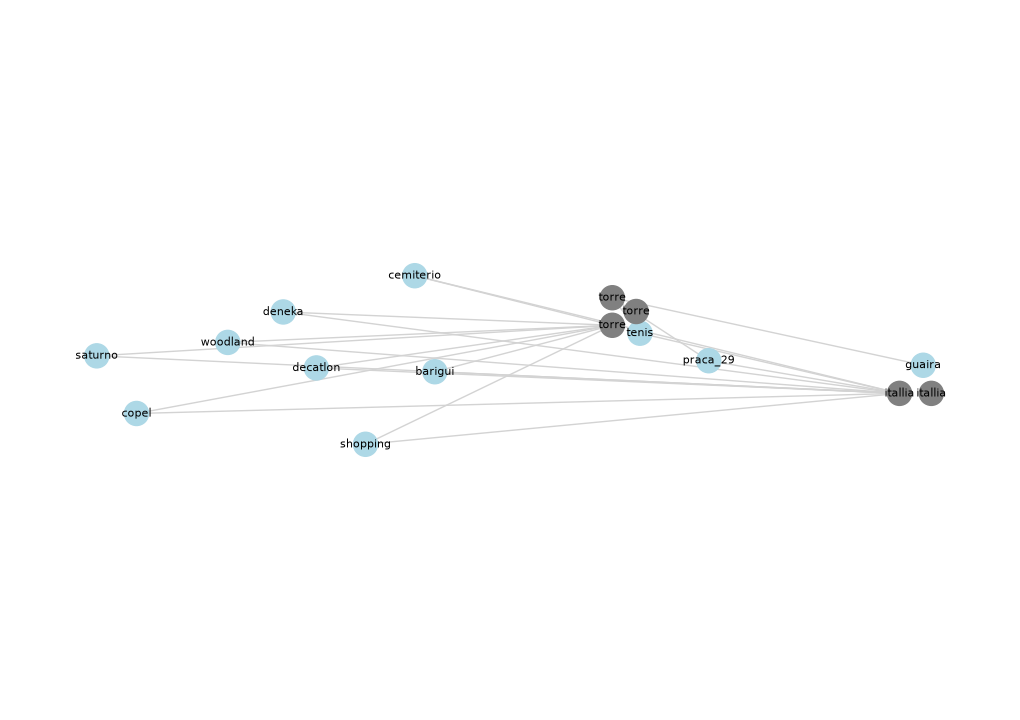

In [8]:
# Optional pre-metric inspection/tuning.
apply_rotation = False
prune_empty = False

if not cell.graph.candidate_edges:
    raise RuntimeError("Run the candidate construction cell first.")

rotation_report = cell.suggest_sector_rotation(
    step_deg=5.0,
    uncovered_weight=10.0,
    imbalance_weight=1.0,
    apply=apply_rotation,
)

if apply_rotation:
    cell.build_primary_candidates(
        sector_aware=True,
        limit_m=None,
        degree=None,
    )

prune_report = cell.prune_empty_sectors(apply=False)
if prune_empty:
    cell.prune_empty_sectors(apply=True)
    cell.build_primary_candidates(
        sector_aware=True,
        limit_m=None,
        degree=None,
    )
    prune_report = cell.prune_empty_sectors(apply=False)

sector_report = cell.sector_candidate_table()
candidate_report = reports.edge_table(cell.graph, "candidate")

display(sector_report)
display(rotation_report)
display(prune_report)
display(candidate_report.head(20))

G_candidate = cell.graph.candidate_graph(
    candidate_edges=cell.graph.candidate_edges,
)
reports.draw_network_graph(
    G_candidate,
    label_mode="site",
    figsize=(10, 7),
    spread_same_position=True,
    spread_radius=150,
)


## 5. Fast Test With Fake Metrics

Use this while developing planner behavior. It does not call the geo service.

In [9]:
rpl_by_id = {node.node_id: node for node in cell.graph.rpl_nodes()}

fake_metrics = {}
for src, dst in cell.graph.candidate_edges:
    src_node = rpl_by_id[src]
    dst_node = rpl_by_id[dst]
    distance_m = math.hypot(
        dst_node.pos_utm[0] - src_node.pos_utm[0],
        dst_node.pos_utm[1] - src_node.pos_utm[1],
    )
    fake_metrics[(src, dst)] = round(max(1.0, distance_m / 1000.0), 3)

cell.graph.edge_metrics = fake_metrics
reports.edge_table(cell.graph, "metric").head(20)

,src,dst,kind,rule,src_site,dst_site,src_tech,dst_tech,src_freq_mhz,dst_freq_mhz,src_mount_height_m,dst_mount_height_m,metric
0,torre:d0:i1,tenis:d0:i0,rf,cell_primary,torre,tenis,lte,lte,400.0,400.0,100.0,7.0,1.000
1,torre:d0:i1,praca_29:d0:i0,rf,cell_primary,torre,praca_29,lte,lte,400.0,400.0,100.0,7.0,1.000
2,torre:d0:i2,barigui:d0:i0,rf,cell_primary,torre,barigui,lte,lte,400.0,400.0,100.0,7.0,1.838
3,torre:d0:i2,cemiterio:d0:i0,rf,cell_primary,torre,cemiterio,lte,lte,400.0,400.0,100.0,7.0,1.967
4,itallia:d0:i1,praca_29:d0:i0,rf,cell_primary,itallia,praca_29,lte,lte,400.0,400.0,30.0,7.0,1.973
5,itallia:d0:i1,tenis:d0:i0,rf,cell_primary,itallia,tenis,lte,lte,400.0,400.0,30.0,7.0,2.659
6,torre:d0:i2,shopping:d0:i0,rf,cell_primary,torre,shopping,lte,lte,400.0,400.0,100.0,7.0,2.709
7,torre:d0:i1,guaira:d0:i0,rf,cell_primary,torre,guaira,lte,lte,400.0,400.0,100.0,7.0,2.901
8,torre:d0:i2,decatlon:d0:i0,rf,cell_primary,torre,decatlon,lte,lte,400.0,400.0,100.0,7.0,2.914
9,torre:d0:i2,deneka:d0:i0,rf,cell_primary,torre,deneka,lte,lte,400.0,400.0,100.0,7.0,3.177


In [10]:
cell.run_rpl()
cell.graph.rpl_result_counts()

{'nodes': 13, 'edges': 11}

In [11]:
cell.service_table()

,site_id,node_id,tech,served,parent,parent_site_id,parent_tech,metric,rank
0,copel,copel:d0:i0,lte,True,torre:d0:i2,torre,lte,4.661,4.661
1,tenis,tenis:d0:i0,lte,True,torre:d0:i1,torre,lte,1.000,1.000
2,praca_29,praca_29:d0:i0,lte,True,torre:d0:i1,torre,lte,1.000,1.000
3,woodland,woodland:d0:i0,lte,True,torre:d0:i2,torre,lte,3.712,3.712
4,deneka,deneka:d0:i0,lte,True,torre:d0:i2,torre,lte,3.177,3.177
5,cemiterio,cemiterio:d0:i0,lte,True,torre:d0:i2,torre,lte,1.967,1.967
6,saturno,saturno:d0:i0,lte,True,torre:d0:i2,torre,lte,4.953,4.953
7,decatlon,decatlon:d0:i0,lte,True,torre:d0:i2,torre,lte,2.914,2.914
8,shopping,shopping:d0:i0,lte,True,torre:d0:i2,torre,lte,2.709,2.709
9,barigui,barigui:d0:i0,lte,True,torre:d0:i2,torre,lte,1.838,1.838


In [12]:
reports.edge_table(cell.graph, "result")

,src,dst,kind,rule,src_site,dst_site,src_tech,dst_tech,src_freq_mhz,dst_freq_mhz,src_mount_height_m,dst_mount_height_m,metric
0,copel:d0:i0,torre:d0:i2,rf,cell_primary,copel,torre,lte,lte,400.0,400.0,7.0,100.0,4.661
1,tenis:d0:i0,torre:d0:i1,rf,cell_primary,tenis,torre,lte,lte,400.0,400.0,7.0,100.0,1.000
2,praca_29:d0:i0,torre:d0:i1,rf,cell_primary,praca_29,torre,lte,lte,400.0,400.0,7.0,100.0,1.000
3,torre:d0:i1,guaira:d0:i0,rf,cell_primary,torre,guaira,lte,lte,400.0,400.0,100.0,7.0,2.901
4,torre:d0:i2,woodland:d0:i0,rf,cell_primary,torre,woodland,lte,lte,400.0,400.0,100.0,7.0,3.712
5,torre:d0:i2,deneka:d0:i0,rf,cell_primary,torre,deneka,lte,lte,400.0,400.0,100.0,7.0,3.177
6,torre:d0:i2,cemiterio:d0:i0,rf,cell_primary,torre,cemiterio,lte,lte,400.0,400.0,100.0,7.0,1.967
7,torre:d0:i2,saturno:d0:i0,rf,cell_primary,torre,saturno,lte,lte,400.0,400.0,100.0,7.0,4.953
8,torre:d0:i2,decatlon:d0:i0,rf,cell_primary,torre,decatlon,lte,lte,400.0,400.0,100.0,7.0,2.914
9,torre:d0:i2,shopping:d0:i0,rf,cell_primary,torre,shopping,lte,lte,400.0,400.0,100.0,7.0,2.709


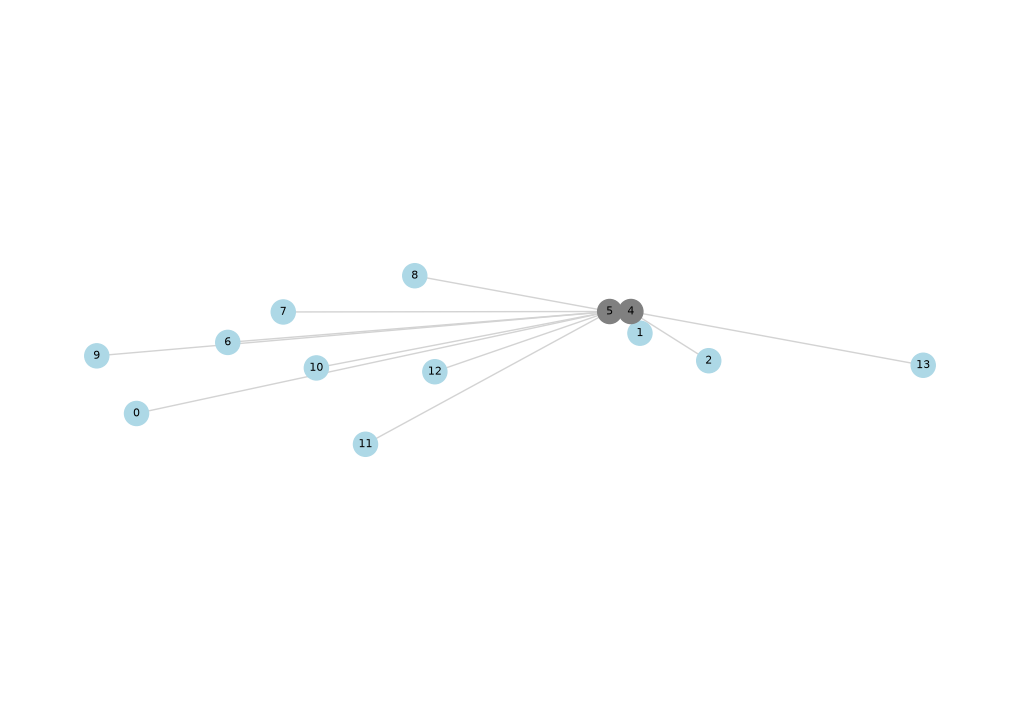

In [13]:
reports.draw_network_graph(
    cell.graph.rpl.G_res,
    label_mode="index",
    figsize=(10, 7),
    spread_same_position=True,
    spread_radius=100,
)

## 6. Optional Real Geo Metrics

Run this section when the planning service is available. Keep the same `geo` pool alive while tuning sectors so environmental features are cached by `(tx, rx, heights, freq)`. `GraphPlanner` enriches each geo response into `{tx, rx, features}` before calling the metric.

In [ ]:
# geo = AsyncGeoServicePool(
#     base_url="http://planning-service:8080",
#     user_prefix="cell-planner-demo",
#     pool_size=1,
#     timeout=180,
# )
#
# real_metrics = await cell.compute_metrics(
#     geo,
#     manage_geo=True,
# )
#
# print("computed real metrics:", len(real_metrics))
# reports.edge_table(cell.graph, "metric").head(20)

## 6.1 Inspect Enriched Metric Context

After real metrics run, each edge stores the metric input record with separate `tx`, `rx`, and environmental `features`.


In [ ]:
# first_edge = next(iter(cell.graph.edge_features))
# first_edge, cell.graph.edge_features[first_edge]


In [ ]:
# cell.run_rpl()
# cell.service_table()

## 7. Development Notes

Next features to add here:

- sector antenna profiles and visual sector validation
- quality threshold / served-vs-unserved classification
- candidate cell selection
- relay recovery from unserved clients